# Titanic Dataset Analysis
Comprehensive analysis including data exploration, preprocessing, model training, and feature importance visualization.

## Import Required Libraries

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import shap
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
import ipywidgets as widgets
from ipywidgets import interact

## Load Dataset

In [2]:
df = pd.read_csv("train.csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## Exploratory Data Analysis (EDA)

### Check Missing Values

In [3]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

### Visualize Survival Rate

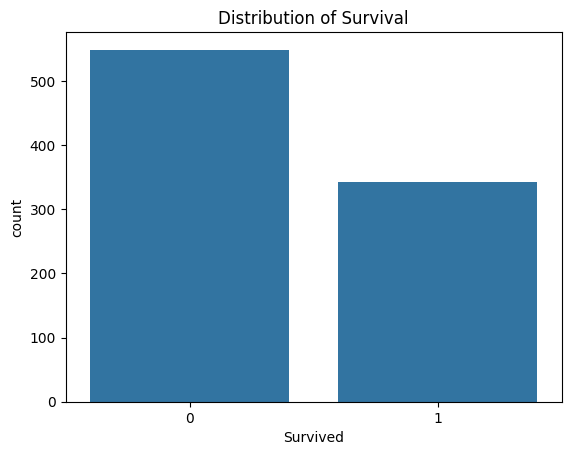

In [6]:
sns.countplot(x="Survived", data=df)
plt.title("Distribution of Survival")
plt.show()

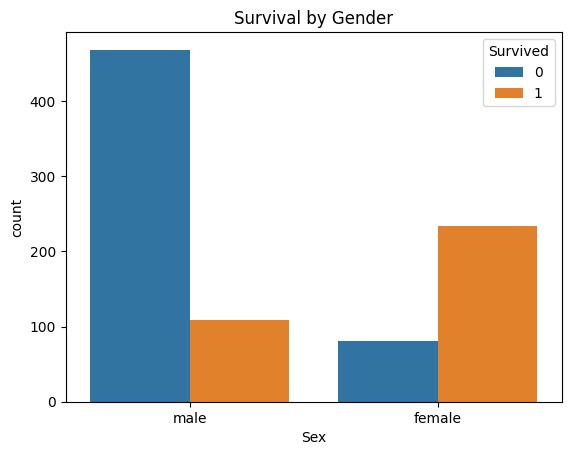

In [8]:
sns.countplot(x="Sex", hue="Survived", data=df)
plt.title("Survival by Gender")
plt.show()

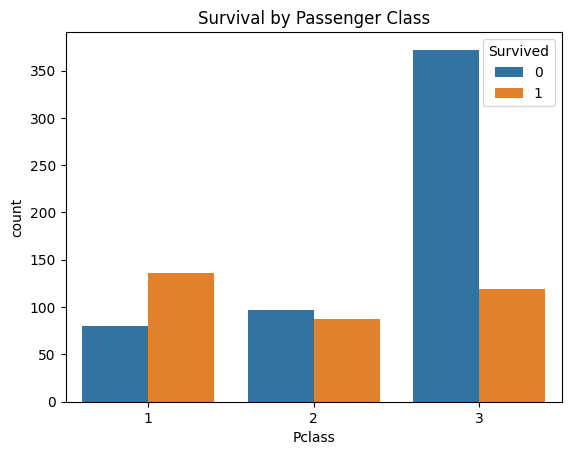

In [10]:
sns.countplot(x="Pclass", hue="Survived", data=df)
plt.title("Survival by Passenger Class")
plt.show()

## Data Processing

### Fill Missing Values

In [11]:
df["Age"] = df["Age"].fillna(df["Age"].median())
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

### Encode Categorical Variables

In [12]:
data = pd.get_dummies(df, columns=["Sex", "Embarked"])

## Feature Engineering

### Create Family Size

In [13]:
data["FamilySize"] = df["SibSp"] + df["Parch"] + 1

### Additional Feature Engineering

In [14]:
# Extract deck from cabin
df["Deck"] = df["Cabin"].str[0]
df["Deck"].fillna("Unknown")

# Extract titles from name
df["Title"] = df["Name"].str.extract(' ([A-Za-z]+)\\.', expand=False)

# Group rare titles
rare_titles = ["Lady", "Countess", "Capt", "Col", "Don", "Dr", "Rev", "Sir", "Jonkheer"]
df["Title"] = df["Title"].replace(rare_titles, "Rare")

## Intermediate Analysis

### Survival Distribution by Age

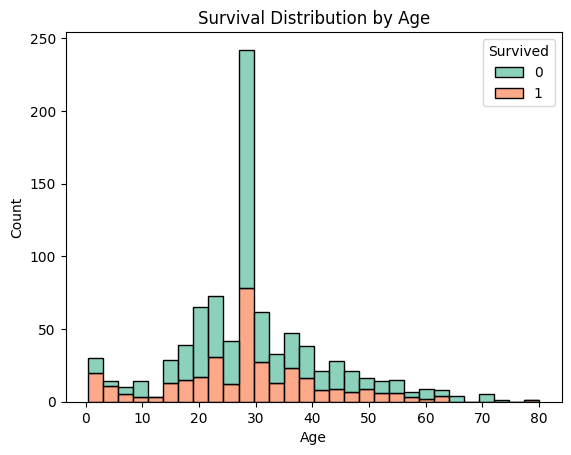

In [15]:
sns.histplot(data=df, x="Age", hue="Survived", multiple="stack", palette="Set2")
plt.title("Survival Distribution by Age")
plt.show()

### Survival by Class and Sex

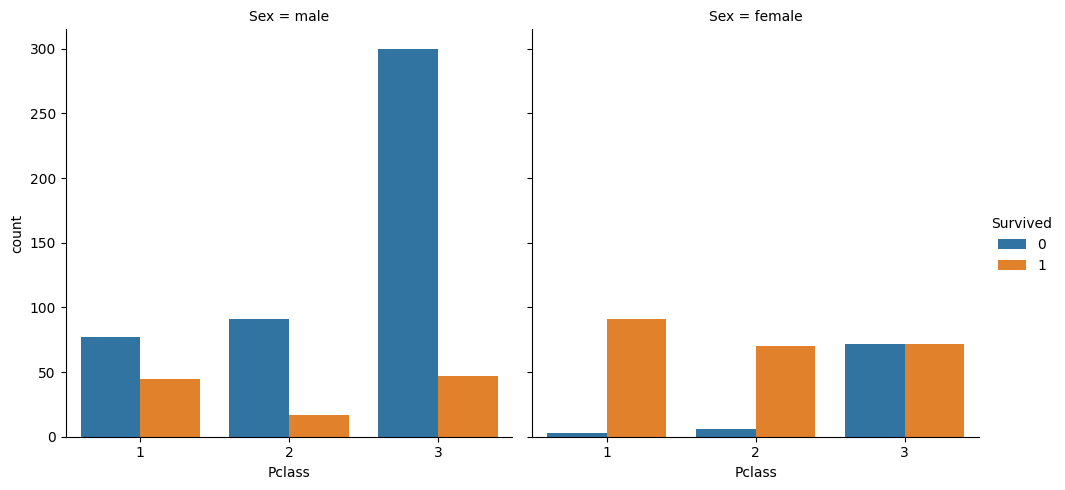

In [16]:
sns.catplot(x="Pclass", hue="Survived", col="Sex", kind="count", data=df)
plt.show()

## Model Training

### Prepare Features and Split Data

In [17]:
features = ["Pclass", "Age", "Fare", "FamilySize", "Sex_female", "Sex_male", "Embarked_C", "Embarked_Q", "Embarked_S"]
X = data[features]
y = data["Survived"]

# Split into train/test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### Train Random Forest Model

In [18]:
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

### Model Evaluation

In [19]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.8324022346368715
              precision    recall  f1-score   support

           0       0.85      0.87      0.86       105
           1       0.81      0.78      0.79        74

    accuracy                           0.83       179
   macro avg       0.83      0.83      0.83       179
weighted avg       0.83      0.83      0.83       179



### Feature Importance

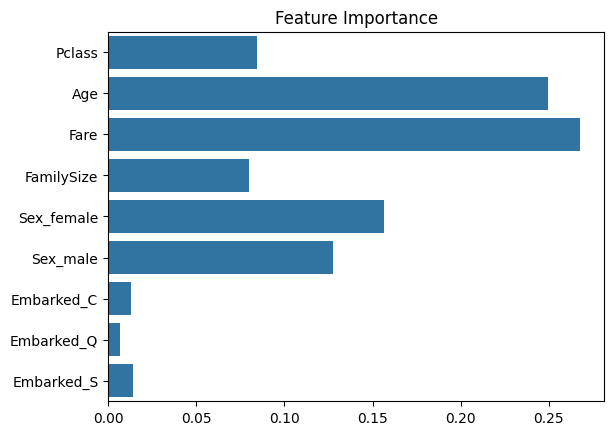

In [20]:
importances = model.feature_importances_
sns.barplot(x=importances, y=features)
plt.title("Feature Importance")
plt.show()

## Model Comparison

In [25]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=500),
    "Random Forest": RandomForestClassifier(n_estimators=100),
    "Gradient Boosting": GradientBoostingClassifier()
}

results = {}
for name, clf in models.items():
    clf.fit(X_train, y_train)
    results[name] = accuracy_score(y_test, clf.predict(X_test))

pd.DataFrame.from_dict(results, orient="index", columns=["Accuracy"])

,Accuracy
Logistic Regression,0.804469
Random Forest,0.821229
Gradient Boosting,0.804469


## Hyperparameter Tuning

In [22]:
param_grid = {
    "n_estimators": [50, 100, 200],
    "max_depth": [None, 10, 20]
}

grid = GridSearchCV(RandomForestClassifier(random_state=42), param_grid, cv=5)
grid.fit(X_train, y_train)
print("Best Parameters:", grid.best_params_)

Best Parameters: {'max_depth': 10, 'n_estimators': 100}


## Model Explainability with SHAP

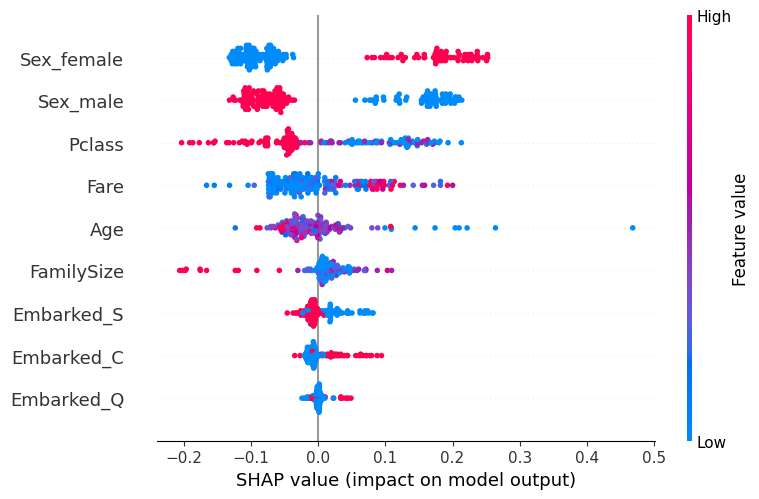

In [23]:
explainer = shap.TreeExplainer(grid.best_estimator_)
shap_values = explainer.shap_values(X_test)
shap.summary_plot(shap_values[:, :, 1], X_test, feature_names=features)

## Interactive Analysis with Widgets

In [29]:
def survival_explorer(age_cutoff=18, pclass=1, sex="male"):
    subset = df[(df["Age"] <= age_cutoff) & 
                  (df["Pclass"] == pclass) & 
                  (df["Sex"] == sex)]
    sns.countplot(x="Sex", hue="Survived", data=subset)
    plt.title(f"Survival for {sex} in Class {pclass}, Age <= {age_cutoff}")
    plt.show()

widgets.interact(survival_explorer, age_cutoff=(0,80), pclass=[1,2,3], sex=["male","female"])


interactive(children=(IntSlider(value=18, description='age_cutoff', max=80), Dropdown(description='pclass', op…

<function __main__.survival_explorer(age_cutoff=18, pclass=1, sex='male')>